# Kaggle CrackTrack Reproduction Notebook

This notebook consolidates the full local reproduction workflow in one place.

It includes:
- Kaggle dataset download via `kagglehub`
- Kaggle kernel pull attempt + output fallback
- Segmentation data preparation
- YOLO segmentation training
- Evaluation and result summarization

## 1) Notebook Setup and Dependencies

Import required libraries and ensure the key packages are available.

In [2]:
import os
import sys
import json
import shutil
import subprocess
from pathlib import Path

PYTHON_EXEC = sys.executable

# Install missing runtime dependencies used in this workflow.
subprocess.run([PYTHON_EXEC, "-m", "pip", "install", "-q", "kaggle", "kagglehub"], check=True)

import kagglehub


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip


## 2) Runtime Configuration and Constants

Define project paths, commands, and run configuration values.

In [ ]:
PROJECT_ROOT = Path.cwd()
KAGGLE_SOURCES = PROJECT_ROOT / "kaggle_sources"
KERNEL_DIR = KAGGLE_SOURCES / "cracktrack"
KERNEL_OUTPUT_DIR = KAGGLE_SOURCES / "cracktrack_output"
DATASET_LOCAL_DIR = KAGGLE_SOURCES / "concrete-crack-images"

LOCAL_REPRO_ROOT = PROJECT_ROOT / "local_repro"
RAW_SEG_DIR = LOCAL_REPRO_ROOT / "raw_segmentation"
SEG_YOLO_DIR = LOCAL_REPRO_ROOT / "segment_yolo"
RUNS_DIR = PROJECT_ROOT / "runs"

TRAIN_NAME = "cracktrack_improved_m_adamw_100"
DATASET_HANDLE = "jakubniemiec/concrete-crack-images"
KERNEL_HANDLE = "yoganandparab/cracktrack"
KAGGLE_EXEC = [PYTHON_EXEC, "-m", "kaggle"]

PROJECT_ROOT, DATASET_LOCAL_DIR

## 3) Copy Existing Utility Functions

Helpers for shell execution, path management, JSON loading, and safe symlink handling.

In [4]:
def run_cmd(cmd, cwd=PROJECT_ROOT, check=True):
    print(f"\n$ {' '.join(cmd)}")
    result = subprocess.run(
        cmd,
        cwd=str(cwd),
        text=True,
        capture_output=True,
    )
    if result.stdout:
        print(result.stdout)
    if result.stderr:
        print(result.stderr)
    if check and result.returncode != 0:
        raise RuntimeError(f"Command failed with exit code {result.returncode}: {' '.join(cmd)}")
    return result


def ensure_clean_dir(path: Path):
    path.mkdir(parents=True, exist_ok=True)
    return path


def replace_path(path: Path):
    if path.is_symlink() or path.exists():
        if path.is_dir() and not path.is_symlink():
            shutil.rmtree(path)
        else:
            path.unlink()


def safe_symlink(src: Path, dst: Path):
    replace_path(dst)
    dst.symlink_to(src)


def read_json(path: Path):
    return json.loads(path.read_text())

## 4) Copy Existing Classes and Core Logic

Core pipeline functions that orchestrate the existing repo scripts in dependency order.

In [ ]:
def download_kaggle_assets():
    ensure_clean_dir(KAGGLE_SOURCES)
    ensure_clean_dir(KERNEL_DIR)

    # 1) Pull kernel source (may fail without Kaggle API credentials)
    pull_res = run_cmd(
        KAGGLE_EXEC + ["kernels", "pull", KERNEL_HANDLE, "--path", str(KERNEL_DIR)],
        check=False,
    )
    if pull_res.returncode != 0:
        print("Kernel pull failed (likely missing Kaggle API auth). Continuing with output fallback.")

    # 2) Download notebook outputs as fallback
    output_path = Path(kagglehub.notebook_output_download(KERNEL_HANDLE))
    replace_path(KERNEL_OUTPUT_DIR)
    shutil.copytree(output_path, KERNEL_OUTPUT_DIR)

    # 3) Download dataset
    dataset_cache_path = Path(kagglehub.dataset_download(DATASET_HANDLE))
    replace_path(DATASET_LOCAL_DIR)
    shutil.copytree(dataset_cache_path, DATASET_LOCAL_DIR)

    return {
        "kernel_pull_code": pull_res.returncode,
        "kernel_output_path": str(KERNEL_OUTPUT_DIR),
        "dataset_path": str(DATASET_LOCAL_DIR),
    }


def prepare_segmentation_data():
    ensure_clean_dir(LOCAL_REPRO_ROOT)
    ensure_clean_dir(RAW_SEG_DIR)

    images_src = DATASET_LOCAL_DIR / "images"
    masks_src = DATASET_LOCAL_DIR / "masks"
    if not images_src.exists() or not masks_src.exists():
        raise FileNotFoundError("Dataset images/masks not found in local Kaggle dataset copy.")

    safe_symlink(images_src.resolve(), RAW_SEG_DIR / "images")
    safe_symlink(masks_src.resolve(), RAW_SEG_DIR / "masks")

    run_cmd([
        PYTHON_EXEC, "src/prepare_segment_data.py",
        "--data_root", "local_repro",
        "--output_dir", "local_repro/segment_yolo",
        "--seed", "42",
    ])


def train_and_evaluate():
    run_cmd([
        PYTHON_EXEC, "src/train_yolo_segment.py",
        "--data_yaml", "local_repro/segment_yolo/crack-seg.yaml",
        "--runs_dir", "./runs",
        "--model", "yolov8m-seg.pt",
        "--epochs", "100",
        "--batch", "8",
        "--imgsz", "256",
        "--patience", "25",
        "--workers", "2",
        "--optimizer", "AdamW",
        "--lr0", "0.001",
        "--lrf", "0.1",
        "--mask_ratio", "1",
        "--name", TRAIN_NAME,
        "--exist_ok",
    ])

    run_cmd([
        PYTHON_EXEC, "src/eval_segment.py",
        "--model", f"runs/segment/{TRAIN_NAME}/weights/best.pt",
        "--data_yaml", "local_repro/segment_yolo/crack-seg.yaml",
        "--split", "test",
        "--imgsz", "256",
        "--save_worst", "10",
        "--save_best", "5",
    ])

## 5) Input Loading and Preprocessing

Download Kaggle assets and prepare YOLO segmentation dataset structure from `images/` and `masks/`.

In [6]:
download_info = download_kaggle_assets()
prepare_segmentation_data()
download_info


$ /usr/local/bin/python3 -m kaggle kernels pull yoganandparab/cracktrack --path /Users/anton/Documents/GitHub/Final_Year_Project/kaggle_sources/cracktrack
You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication

Kernel pull failed (likely missing Kaggle API auth). Continuing with output fallback.
You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication

Kernel pull failed (likely missing Kaggle API auth). Continuing with output fallback.

$ /usr/local/bin/python3 src/prepare_segment_data.py --data_root local_repro --output_dir local_repro/segment_yolo --seed 42

$ /usr/local/bin/python3 src/prepare_segment_data.py --data_root local_repro --output_dir local_repro/segment_yolo --seed 42
YOLO SEGMENTATION DATA PREPARATION
Data root: /Users/anton/D

{'kernel_pull_code': 1,
 'kernel_output_path': '/Users/anton/Documents/GitHub/Final_Year_Project/kaggle_sources/cracktrack_output',
 'dataset_path': '/Users/anton/Documents/GitHub/Final_Year_Project/kaggle_sources/concrete-crack-images'}

## 6) Main Execution Pipeline

Train YOLO segmentation and run test-set evaluation.

In [12]:
train_and_evaluate()


$ /usr/local/bin/python3 src/train_yolo_segment.py --data_yaml local_repro/segment_yolo/crack-seg.yaml --runs_dir ./runs --model yolov8s-seg.pt --epochs 50 --batch 8 --imgsz 256 --patience 10 --workers 2 --name cracktrack_repro_8s_50 --exist_ok
YOLO SEGMENTATION TRAINING
Data YAML: /Users/anton/Documents/GitHub/Final_Year_Project/local_repro/segment_yolo/crack-seg.yaml
Runs directory: /Users/anton/Documents/GitHub/Final_Year_Project/runs
Model: yolov8s-seg.pt
Device: auto
Seed: 42

Loading model: yolov8s-seg.pt
✓ Model loaded

Training configuration:
{
  "data": "/Users/anton/Documents/GitHub/Final_Year_Project/local_repro/segment_yolo/crack-seg.yaml",
  "epochs": 50,
  "batch": 8,
  "imgsz": 256,
  "patience": 10,
  "weight_decay": 0.0005,
  "lr0": 0.01,
  "lrf": 0.01,
  "device": "",
  "seed": 42,
  "workers": 2,
  "project": "/Users/anton/Documents/GitHub/Final_Year_Project/runs/segment",
  "name": "cracktrack_repro_8s_50",
  "exist_ok": true,
  "pretrained": true,
  "optimizer": "

## 7) Output Validation and Quick Tests

Verify that expected files exist and print core quality metrics.

In [13]:
metrics_path = RUNS_DIR / "segment" / TRAIN_NAME / "eval" / "metrics_test.json"
best_model_path = RUNS_DIR / "segment" / TRAIN_NAME / "weights" / "best.pt"

assert SEG_YOLO_DIR.exists(), "Prepared segmentation directory missing"
assert best_model_path.exists(), "Best model checkpoint not found"
assert metrics_path.exists(), "Evaluation metrics JSON not found"

metrics = read_json(metrics_path)
summary = {
    "num_images": metrics["num_images"],
    "dice_mean": metrics["dice"]["mean"],
    "iou_mean": metrics["iou"]["mean"],
}
summary

{'num_images': 80,
 'dice_mean': 0.7773763707312001,
 'iou_mean': 0.6778516042278285}

## 8) Save Results and Artifacts

Persist a compact reproduction summary and list key output locations.

In [14]:
artifact_manifest = {
    "project_root": str(PROJECT_ROOT),
    "dataset_local_dir": str(DATASET_LOCAL_DIR),
    "kernel_dir": str(KERNEL_DIR),
    "kernel_output_dir": str(KERNEL_OUTPUT_DIR),
    "segment_data_yaml": str(SEG_YOLO_DIR / "crack-seg.yaml"),
    "best_model": str(best_model_path),
    "eval_metrics": str(metrics_path),
    "summary": summary,
}

summary_path = KAGGLE_SOURCES / "cracktrack_repro_summary.json"
summary_path.parent.mkdir(parents=True, exist_ok=True)
summary_path.write_text(json.dumps(artifact_manifest, indent=2))

print(f"Saved summary: {summary_path}")
artifact_manifest

Saved summary: /Users/anton/Documents/GitHub/Final_Year_Project/kaggle_sources/cracktrack_repro_summary.json


{'project_root': '/Users/anton/Documents/GitHub/Final_Year_Project',
 'dataset_local_dir': '/Users/anton/Documents/GitHub/Final_Year_Project/kaggle_sources/concrete-crack-images',
 'kernel_dir': '/Users/anton/Documents/GitHub/Final_Year_Project/kaggle_sources/cracktrack',
 'kernel_output_dir': '/Users/anton/Documents/GitHub/Final_Year_Project/kaggle_sources/cracktrack_output',
 'segment_data_yaml': '/Users/anton/Documents/GitHub/Final_Year_Project/local_repro/segment_yolo/crack-seg.yaml',
 'best_model': '/Users/anton/Documents/GitHub/Final_Year_Project/runs/segment/cracktrack_repro_8s_50/weights/best.pt',
 'eval_metrics': '/Users/anton/Documents/GitHub/Final_Year_Project/runs/segment/cracktrack_repro_8s_50/eval/metrics_test.json',
 'summary': {'num_images': 80,
  'dice_mean': 0.7773763707312001,
  'iou_mean': 0.6778516042278285}}

## 9) Visualizations

This section adds quick visuals for training dynamics, metric distributions, and qualitative examples.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

run_dir = RUNS_DIR / "segment" / TRAIN_NAME
eval_dir = run_dir / "eval"
results_csv = run_dir / "results.csv"
metrics_json = eval_dir / "metrics_test.json"

results_df = pd.read_csv(results_csv)
metrics_data = read_json(metrics_json)
per_image_df = pd.DataFrame(metrics_data["per_image"])

print(f"Run dir: {run_dir}")
print(f"Loaded {len(results_df)} training epochs and {len(per_image_df)} test images")

Run dir: /Users/anton/Documents/GitHub/Final_Year_Project/runs/segment/cracktrack_repro_8s_50
Loaded 24 training epochs and 80 test images


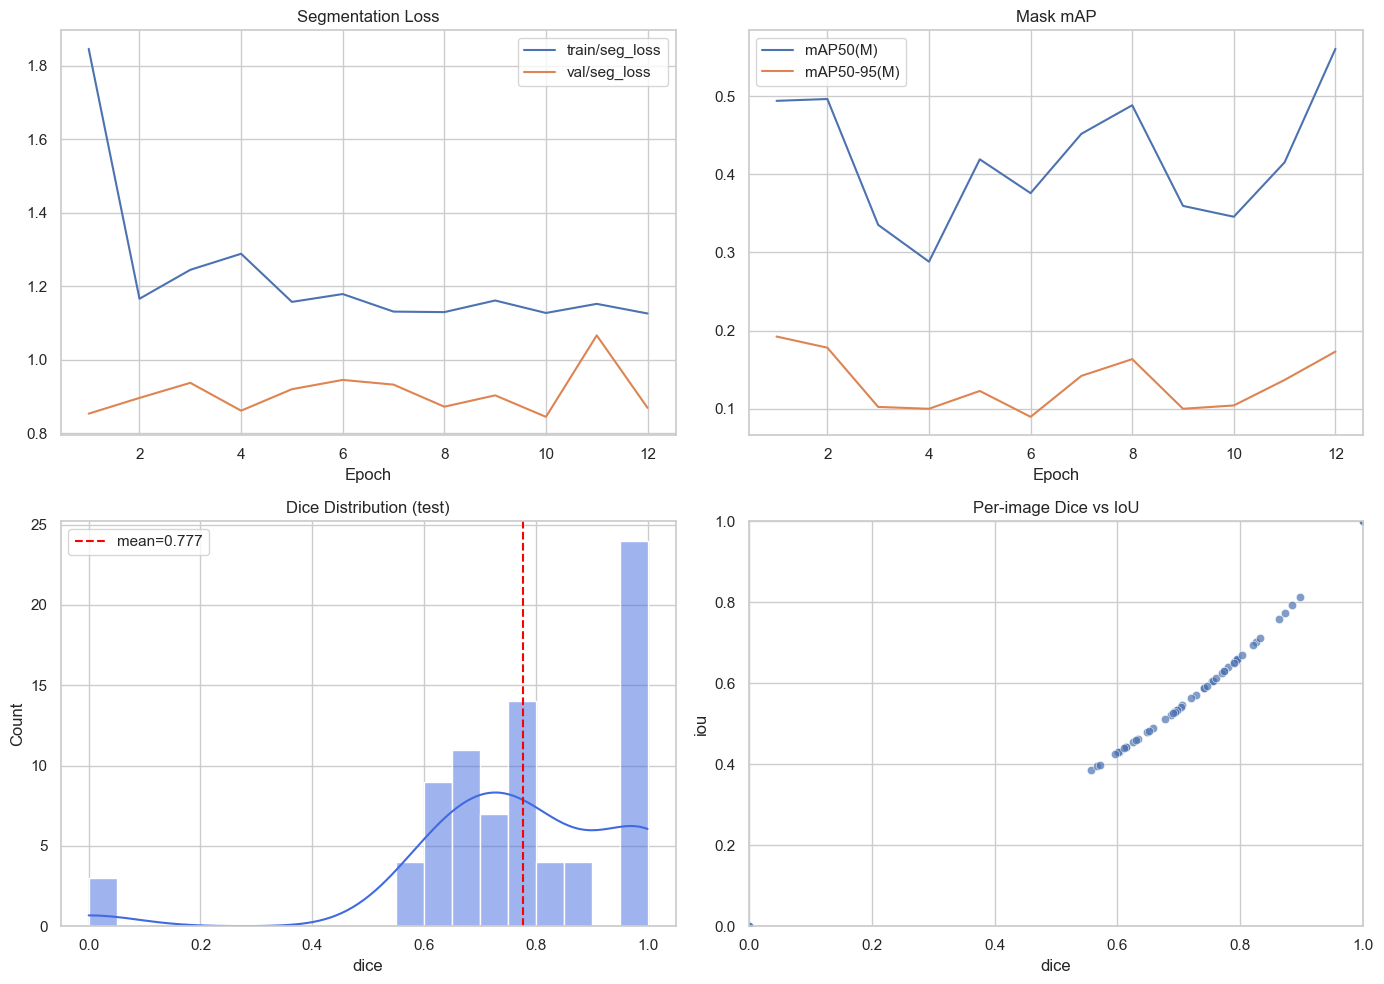

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(results_df["epoch"], results_df["train/seg_loss"], label="train/seg_loss")
axes[0, 0].plot(results_df["epoch"], results_df["val/seg_loss"], label="val/seg_loss")
axes[0, 0].set_title("Segmentation Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].legend()

axes[0, 1].plot(results_df["epoch"], results_df["metrics/mAP50(M)"], label="mAP50(M)")
axes[0, 1].plot(results_df["epoch"], results_df["metrics/mAP50-95(M)"], label="mAP50-95(M)")
axes[0, 1].set_title("Mask mAP")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].legend()

sns.histplot(per_image_df["dice"], bins=20, kde=True, ax=axes[1, 0], color="royalblue")
axes[1, 0].axvline(metrics_data["dice"]["mean"], color="red", linestyle="--", label=f"mean={metrics_data['dice']['mean']:.3f}")
axes[1, 0].set_title("Dice Distribution (test)")
axes[1, 0].legend()

sns.scatterplot(data=per_image_df, x="dice", y="iou", ax=axes[1, 1], alpha=0.7)
axes[1, 1].set_title("Per-image Dice vs IoU")
axes[1, 1].set_xlim(0, 1)
axes[1, 1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

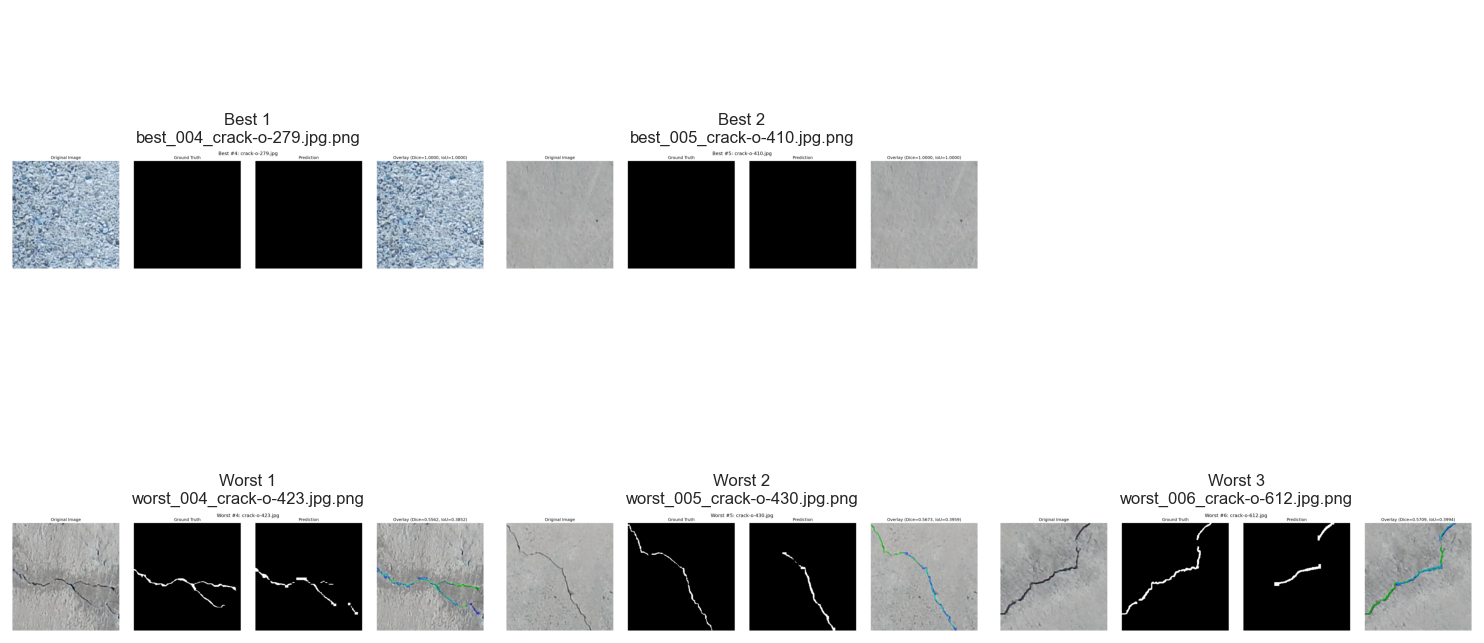

In [20]:
from PIL import Image

best_cases_dir = eval_dir / "best_cases"
worst_cases_dir = eval_dir / "worst_cases"

best_all = sorted(best_cases_dir.glob("*.png"))
worst_all = sorted(worst_cases_dir.glob("*.png"))

# Pick a different slice than the first 3 shown previously.
offset = 3
best_pool = best_all[offset:] if len(best_all) > offset else best_all
worst_pool = worst_all[offset:] if len(worst_all) > offset else worst_all

best_imgs = best_pool[:3]
worst_imgs = worst_pool[:3]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i in range(3):
    if i < len(best_imgs):
        axes[0, i].imshow(Image.open(best_imgs[i]))
        axes[0, i].set_title(f"Best {i+1}\n{best_imgs[i].name}")
    axes[0, i].axis("off")

    if i < len(worst_imgs):
        axes[1, i].imshow(Image.open(worst_imgs[i]))
        axes[1, i].set_title(f"Worst {i+1}\n{worst_imgs[i].name}")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

## 10) Interactive Qualitative Viewer

Use the slider to browse different groups of best and worst predictions without editing code.

In [22]:
import math
import ipywidgets as widgets
from IPython.display import display


def render_case_grid(group_index=0, count=3):
    best_cases_dir = eval_dir / "best_cases"
    worst_cases_dir = eval_dir / "worst_cases"

    best_all = sorted(best_cases_dir.glob("*.png"))
    worst_all = sorted(worst_cases_dir.glob("*.png"))

    start = group_index * count
    best_imgs = best_all[start:start + count]
    worst_imgs = worst_all[start:start + count]

    fig, axes = plt.subplots(2, count, figsize=(5 * count, 8))
    if count == 1:
        axes = np.array([[axes[0]], [axes[1]]])

    for i in range(count):
        if i < len(best_imgs):
            axes[0, i].imshow(Image.open(best_imgs[i]))
            axes[0, i].set_title(f"Best {start + i + 1}\n{best_imgs[i].name}")
        else:
            axes[0, i].set_title("No more best cases")
        axes[0, i].axis("off")

        if i < len(worst_imgs):
            axes[1, i].imshow(Image.open(worst_imgs[i]))
            axes[1, i].set_title(f"Worst {start + i + 1}\n{worst_imgs[i].name}")
        else:
            axes[1, i].set_title("No more worst cases")
        axes[1, i].axis("off")

    plt.tight_layout()
    plt.show()


def build_case_browser(count=3):
    best_total = len(sorted((eval_dir / "best_cases").glob("*.png")))
    worst_total = len(sorted((eval_dir / "worst_cases").glob("*.png")))
    max_groups = max(1, math.ceil(max(best_total, worst_total) / count))

    group_slider = widgets.IntSlider(
        value=0,
        min=0,
        max=max_groups - 1,
        step=1,
        description="Group",
    )
    count_dropdown = widgets.Dropdown(options=[1, 2, 3], value=count, description="Count")

    interactive_view = widgets.interactive_output(
        render_case_grid,
        {"group_index": group_slider, "count": count_dropdown},
    )
    return widgets.VBox([widgets.HBox([group_slider, count_dropdown]), interactive_view])


display(build_case_browser())